# Handcrafted Global Features

This notebook implements and evaluates the handcrafted-feature component of the
traditional image-classification pipeline. It compares colour, texture and shape
descriptors using the same Linear SVM classifier.

The selected `train_mini` images are split into 40 training and 10 validation
images per class. The official iNaturalist validation split is reserved as the
final test set.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Could not locate the project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import save_result
from src.traditional.dataset import build_manifest_from_folders, get_class_names
from src.traditional.features import FEATURES
from src.traditional.run_features import run_descriptor

print("Project root:", PROJECT_ROOT)
print("Available features:", sorted(FEATURES))


Project root: <PROJECT_ROOT>
Available features: ['color_hist', 'color_lbp', 'color_moments', 'hog', 'lbp', 'multiscale_lbp']


In [2]:
# Locate the selected dataset.
DATASET_CANDIDATES = [
    PROJECT_ROOT / "select_train_n_val",
    PROJECT_ROOT.parent / "select_train_n_val",
]
DATASET_ROOT = next((path for path in DATASET_CANDIDATES if path.is_dir()), None)
if DATASET_ROOT is None:
    raise FileNotFoundError("Could not locate select_train_n_val")

TRAIN_DIR = DATASET_ROOT / "select_train_mini"
TEST_DIR = DATASET_ROOT / "select_val_mini"
RESULTS_DIR = PROJECT_ROOT / "results"

SEED = 42
VALIDATION_PER_CLASS = 10

# Keep this at 1 for a quick code check. Use None for graded experiments.
LIMIT_PER_CLASS = None

# Enable one experiment section at a time.
RUN_DESCRIPTOR_COMPARISON = False
RUN_ABLATIONS = False
RUN_FINAL_TEST = True

print("Training folder:", TRAIN_DIR)
print("Official test folder:", TEST_DIR)


Training folder: <DATASET_ROOT>/select_train_mini
Official test folder: <DATASET_ROOT>/select_val_mini


In [3]:
manifest = build_manifest_from_folders(
    TRAIN_DIR,
    TEST_DIR,
    validation_per_class=VALIDATION_PER_CLASS,
    seed=SEED,
)
class_names = get_class_names(manifest)

split_counts = manifest.groupby("split").size().rename("images")
per_class_counts = manifest.groupby(["class_id", "split"]).size().unstack(fill_value=0)

display(split_counts)
display(per_class_counts.describe())

assert len(class_names) == 900
assert per_class_counts["train"].eq(40).all()
assert per_class_counts["validation"].eq(10).all()
assert per_class_counts["test"].eq(10).all()
print("Dataset split checks passed.")


split
test           9000
train         36000
validation     9000
Name: images, dtype: int64

split,test,train,validation
count,900.0,900.0,900.0
mean,10.0,40.0,10.0
std,0.0,0.0,0.0
min,10.0,40.0,10.0
25%,10.0,40.0,10.0
50%,10.0,40.0,10.0
75%,10.0,40.0,10.0
max,10.0,40.0,10.0


Dataset split checks passed.


## Experiment helper

Every experiment uses the same split, seed, feature standardisation and Linear
SVM. Only the descriptor or one descriptor parameter changes.


In [4]:
def make_args(descriptor, evaluate_split="validation", **overrides):
    settings = {
        "descriptor": descriptor,
        "evaluate_split": evaluate_split,
        "limit_per_class": LIMIT_PER_CLASS,
        "sgd_alpha": 1e-4,
        "sgd_max_iter": 100,
        "color_bins": 32,
        "color_space": "HSV",
        "grid_size": 1,
        "lbp_points": 8,
        "lbp_radius": 1.0,
        "hog_size": 128,
        "hog_orientations": 9,
        "hog_cell_size": 16,
        "seed": SEED,
    }
    settings.update(overrides)
    return SimpleNamespace(**settings)


def run_experiment(name, args):
    rows, y_score, train_s, test_s = run_descriptor(
        args,
        manifest,
        class_names,
    )
    y_true = rows["class_id"].to_numpy(dtype=np.int64)
    y_pred = np.argmax(y_score, axis=1)
    path, metrics = save_result(
        RESULTS_DIR,
        name,
        y_true,
        y_pred,
        y_score,
        class_names,
        {"train_s": train_s, "test_s": test_s},
        filepaths=rows["filepath"].tolist(),
    )
    record = {
        "method": name,
        "descriptor": args.descriptor,
        "split": args.evaluate_split,
        **metrics,
        "result_path": str(path),
    }
    print(name, "macro_f1:", f"{metrics['macro_f1']:.4f}")
    return record, (rows, y_true, y_pred, y_score)

experiment_records = []
experiment_outputs = {}


## Descriptor comparison

This comparison measures the contribution of different visual cues:

- colour histogram: global colour distribution;
- colour moments: compact colour statistics;
- LBP: local texture;
- multi-scale LBP: texture at several neighbourhood sizes;
- HOG: edge and shape structure;
- colour + LBP: early fusion of complementary colour and texture.


In [5]:
DESCRIPTOR_EXPERIMENTS = [
    ("color_hist_hsv_b32_sgd_svm", make_args("color_hist")),
    ("color_moments_hsv_grid1_sgd_svm", make_args("color_moments")),
    ("lbp_p8_r1_sgd_svm", make_args("lbp")),
    ("multiscale_lbp_sgd_svm", make_args("multiscale_lbp")),
    ("hog_size128_cell16_sgd_svm", make_args("hog")),
    ("color_lbp_hsv_b32_sgd_svm", make_args("color_lbp")),
]

if RUN_DESCRIPTOR_COMPARISON:
    for name, args in DESCRIPTOR_EXPERIMENTS:
        record, output = run_experiment(name, args)
        experiment_records.append(record)
        experiment_outputs[name] = output
else:
    print("Set RUN_DESCRIPTOR_COMPARISON = True to run this section.")


Set RUN_DESCRIPTOR_COMPARISON = True to run this section.


## Single-variable ablation studies

Only one parameter is changed at a time. These experiments should be evaluated
on the internal validation set, not on the final test set.


In [6]:
# Targeted ablations based on the descriptor comparison.
# HSV with 32 bins is already available from the baseline experiment.
ABLATION_EXPERIMENTS = [
    ("color_hist_hsv_b16_sgd_svm", make_args("color_hist", color_bins=16)),
    ("color_hist_hsv_b64_sgd_svm", make_args("color_hist", color_bins=64)),
    (
        "color_hist_rgb_b32_sgd_svm",
        make_args("color_hist", color_space="RGB", color_bins=32),
    ),
]

if RUN_ABLATIONS:
    for name, args in ABLATION_EXPERIMENTS:
        record, output = run_experiment(name, args)
        experiment_records.append(record)
        experiment_outputs[name] = output
else:
    print("Set RUN_ABLATIONS = True to run this section.")


Set RUN_ABLATIONS = True to run this section.


## HSV 64-bin colour and LBP fusion check

The colour ablation shows that HSV with 64 bins is the strongest colour
configuration. This experiment checks whether replacing the 32-bin histogram
in the colour+LBP fusion further improves validation performance.


In [7]:
RUN_FUSION64_CHECK = False

if RUN_FUSION64_CHECK:
    fusion64_args = make_args(
        "color_lbp",
        evaluate_split="validation",
        color_bins=64,
        color_space="HSV",
    )
    fusion64_record, fusion64_output = run_experiment(
        "color_lbp_hsv_b64_sgd_svm",
        fusion64_args,
    )
    experiment_records.append(fusion64_record)
    experiment_outputs["color_lbp_hsv_b64_sgd_svm"] = fusion64_output
    display(pd.DataFrame([fusion64_record]))
else:
    print("Set RUN_FUSION64_CHECK = False to run this section.")


Set RUN_FUSION64_CHECK = False to run this section.


## Validation results

Select the final descriptor using validation macro-F1. Training time includes
feature extraction, scaling and classifier fitting. Test time includes image
loading, feature extraction and prediction.


In [8]:
if experiment_records:
    results_table = pd.DataFrame(experiment_records).sort_values(
        "macro_f1",
        ascending=False,
    )
    display(
        results_table[
            [
                "method",
                "top1_accuracy",
                "top5_accuracy",
                "balanced_accuracy",
                "macro_precision",
                "macro_recall",
                "macro_f1",
                "train_s",
                "test_s",
            ]
        ]
    )

    figure, axis = plt.subplots(figsize=(10, 5))
    ordered = results_table.sort_values("macro_f1")
    axis.barh(ordered["method"], ordered["macro_f1"])
    axis.set_xlabel("Validation macro-F1")
    axis.set_title("Handcrafted feature comparison")
    axis.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run a validation experiment section first.")


Run a validation experiment section first.


## Final held-out test

After validation experiments are complete, copy the single best configuration
below. Do not use the test result to choose another configuration.


In [9]:
# Replace this configuration only using the validation results.
FINAL_METHOD_NAME = "color_lbp_hsv_b64_sgd_svm_final_test"
FINAL_ARGS = make_args(
    "color_lbp",
    evaluate_split="test",
    color_bins=64,
    color_space="HSV",
)

final_output = None
if RUN_FINAL_TEST:
    final_record, final_output = run_experiment(FINAL_METHOD_NAME, FINAL_ARGS)
    display(pd.DataFrame([final_record]))
else:
    print("Set RUN_FINAL_TEST = True only after the final configuration is fixed.")


Extracting color_lbp: 100%|██████████| 9000/9000 [07:26<00:00, 20.14it/s]


color_lbp_hsv_b64_sgd_svm_final_test macro_f1: 0.0140


,method,descriptor,split,top1_accuracy,top5_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,train_s,test_s,ms_per_image,num_samples,result_path
0,color_lbp_hsv_b64_sgd_svm_final_test,color_lbp,test,0.020667,0.066556,0.020667,0.0204,0.020667,0.013974,1817.545583,447.072664,49.67474,9000,/...


## Final-test error analysis

The full confusion matrix uses log-scaled counts. The examples show confident
successes and confident failures for qualitative discussion.


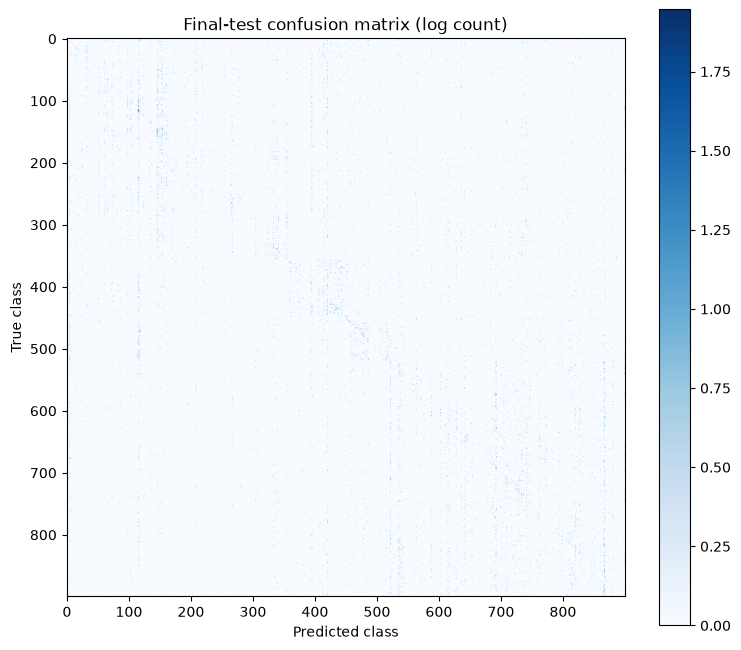

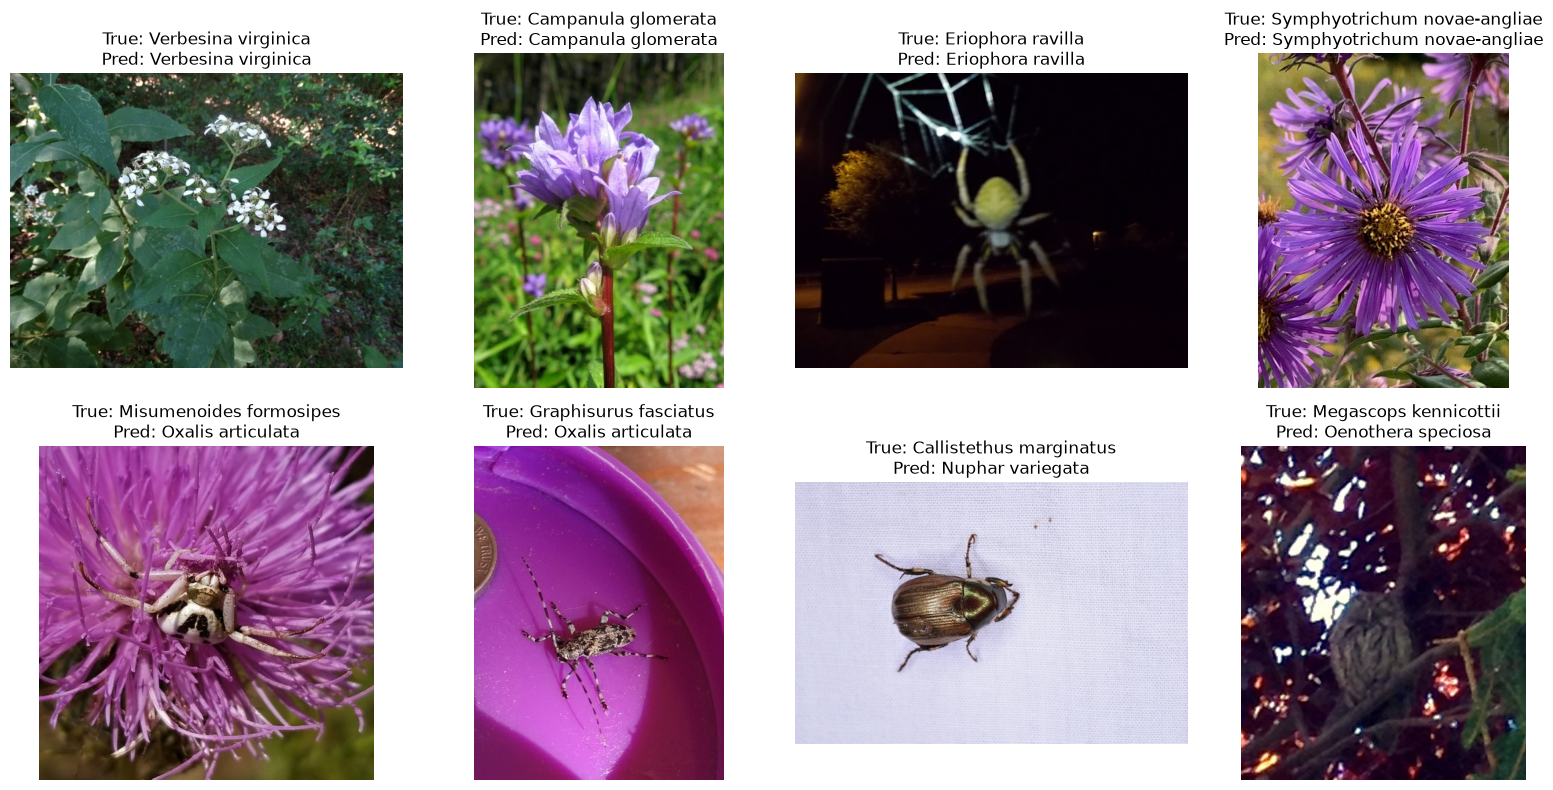

In [ ]:
if final_output is not None:
    rows, y_true, y_pred, y_score = final_output
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
    )

    figure, axis = plt.subplots(figsize=(9, 8))
    image = axis.imshow(np.log1p(matrix), cmap="Blues")
    axis.set_title("Final-test confusion matrix (log count)")
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    figure.colorbar(image, ax=axis)
    plt.show()

    confidence = np.max(y_score, axis=1)
    correct_indices = np.flatnonzero(y_true == y_pred)
    wrong_indices = np.flatnonzero(y_true != y_pred)
    correct_indices = correct_indices[np.argsort(confidence[correct_indices])[-4:]]
    wrong_indices = wrong_indices[np.argsort(confidence[wrong_indices])[-4:]]

    selected = list(correct_indices) + list(wrong_indices)
    figure, axes = plt.subplots(2, 4, figsize=(16, 8))
    for axis, index in zip(axes.ravel(), selected):
        with Image.open(rows.iloc[index]["filepath"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"True: {class_names[y_true[index]]}\n"
            f"Pred: {class_names[y_pred[index]]}"
        )
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Run the final test before producing error analysis.")
